# **IND v. PHL Rainfall**
*Notebook created Jan. 21, 2026*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -----------------------------
# File paths
# -----------------------------
PHL_FILE = r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\02_PHL\weighted_monthly_rainfall.csv"

IND_FILES = {
    "Whole_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_Whole-IND.csv",
    "Central_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_Cen-IND.csv",
    "NE_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_NE-IND.csv",
    "NW_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_NW-IND.csv",
    "Peninsula_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_Pen-IND.csv",
}

# -----------------------------
# Load data
# -----------------------------
phl = pd.read_csv(PHL_FILE)
phl.rename(columns={"year": "Year"}, inplace=True)

ind = {k: pd.read_csv(v) for k, v in IND_FILES.items()}

# -----------------------------
# Restrict to 1979–2020
# -----------------------------
phl = phl[(phl["Year"] >= 1979) & (phl["Year"] <= 2020)]

for k in ind:
    ind[k] = ind[k][(ind[k]["Year"] >= 1979) & (ind[k]["Year"] <= 2020)]

In [2]:
def clean_columns(df):
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)  # remove BOM
        .str.strip()
    )
    return df

for k in ind:
    ind[k] = clean_columns(ind[k])
    print(f"{k} columns:", ind[k].columns.tolist())

Whole_IND columns: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual', 'Winter Season', 'Pre-Monsoon Season', 'Monsoon_Season', 'Post-Monsoon Season']
Central_IND columns: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual', 'Winter Season', 'Pre-Monsoon Season', 'Monsoon_Season', 'Post-Monsoon Season']
NE_IND columns: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual', 'Winter Season', 'Pre-Monsoon Season', 'Monsoon_Season', 'Post-Monsoon Season']
NW_IND columns: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual', 'Winter Season', 'Pre-Monsoon Season', 'Monsoon_Season', 'Post-Monsoon Season']
Peninsula_IND columns: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual', 'Winter Season', 'Pre-Monsoon Season', 'Monsoon_Season', 'Post-Monsoon

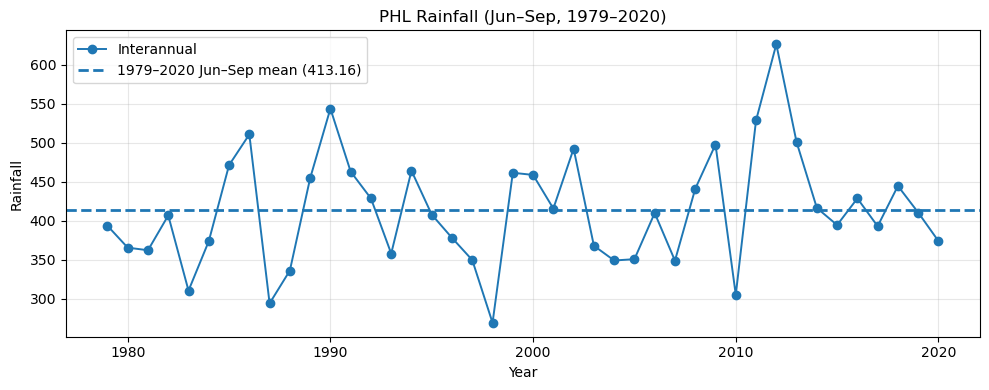

In [3]:
phl_seasonal_mean = phl["annual"].mean()

plt.figure(figsize=(10, 4))
plt.plot(phl["Year"], phl["annual"], marker="o", linewidth=1.4, label="Interannual")
plt.axhline(phl_seasonal_mean, linestyle="--", linewidth=2,
            label=f"1979–2020 Jun–Sep mean ({phl_seasonal_mean:.2f})")

plt.title("PHL Rainfall (Jun–Sep, 1979–2020)")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

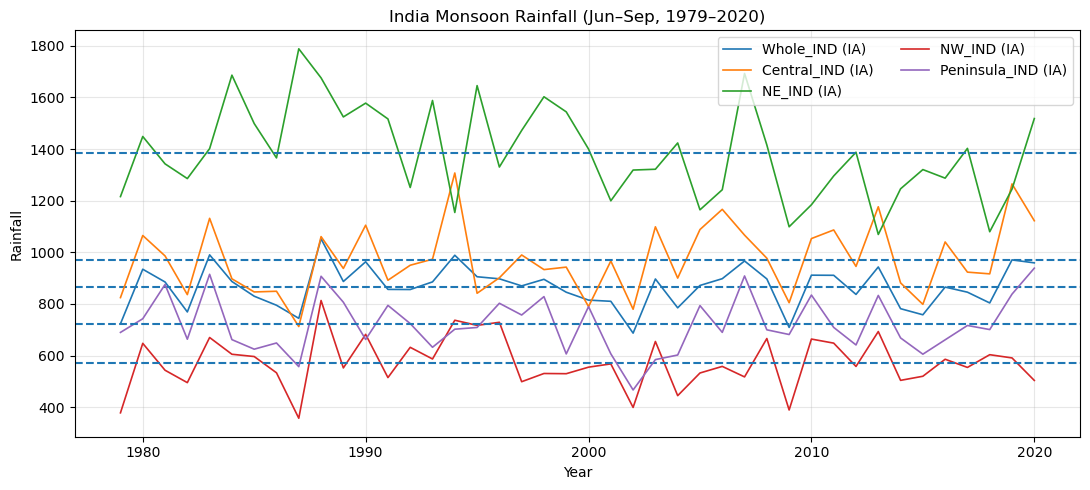

In [4]:
plt.figure(figsize=(11, 5))

for name, df in ind.items():
    mean_val = df["Monsoon_Season"].mean()
    plt.plot(df["Year"], df["Monsoon_Season"], linewidth=1.2, label=f"{name} (IA)")
    plt.axhline(mean_val, linestyle="--", linewidth=1.5)

plt.title("India Monsoon Rainfall (Jun–Sep, 1979–2020)")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.legend(ncol=2)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## **Interannual Relationship**

### **PHL vs Whole IND**

In [5]:
df = pd.merge(
    phl[["Year", "annual"]],
    ind["Whole_IND"][["Year", "Monsoon_Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon_Season"])
print(f"PHL vs Whole India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

PHL vs Whole India (1979–2020) | r = -0.193, p = 0.2203


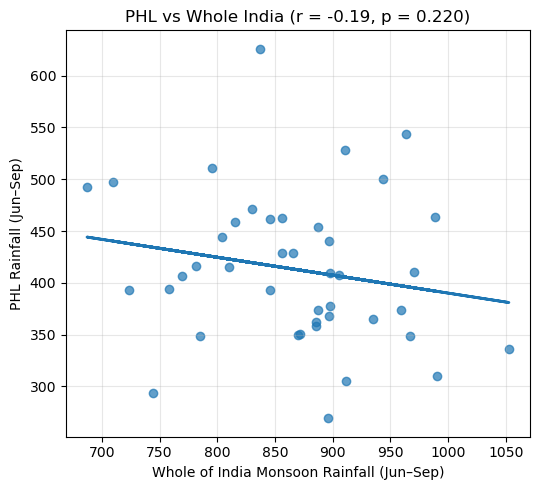

In [6]:
import numpy as np

x = df["Monsoon_Season"]
y = df["annual"]

# Linear fit
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Whole of India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Whole India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **PHL vs Central IND**

In [7]:
df = pd.merge(
    phl[["Year", "annual"]],
    ind["Central_IND"][["Year", "Monsoon_Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon_Season"])
print(f"PHL vs Central India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

PHL vs Central India (1979–2020) | r = -0.036, p = 0.8206


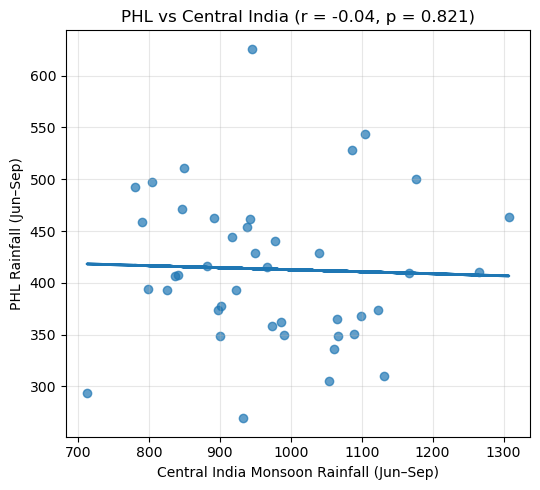

In [8]:
import numpy as np

x = df["Monsoon_Season"]
y = df["annual"]

# Linear fit
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Central India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Central India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **PHL vs NE IND**

In [9]:
df = pd.merge(
    phl[["Year", "annual"]],
    ind["NE_IND"][["Year", "Monsoon_Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon_Season"])
print(f"PHL vs NE India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

PHL vs NE India (1979–2020) | r = -0.291, p = 0.0613


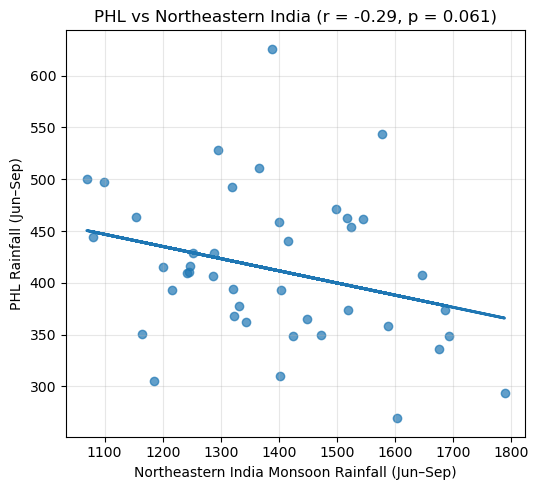

In [10]:
import numpy as np

x = df["Monsoon_Season"]
y = df["annual"]

# Linear fit
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Northeastern India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Northeastern India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **PHL vs NW IND**

In [11]:
df = pd.merge(
    phl[["Year", "annual"]],
    ind["NW_IND"][["Year", "Monsoon_Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon_Season"])
print(f"PHL vs NW India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

PHL vs NW India (1979–2020) | r = 0.038, p = 0.8096


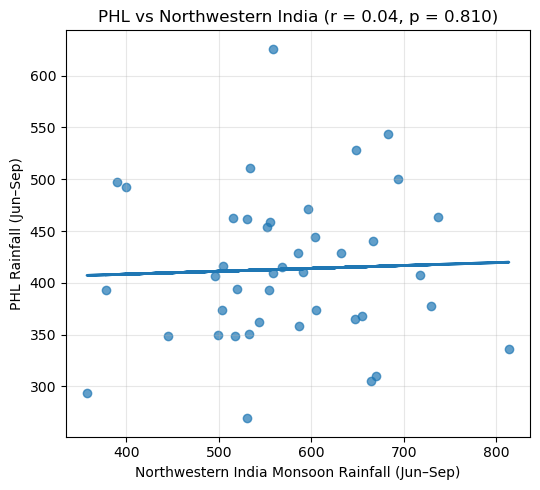

In [12]:
import numpy as np

x = df["Monsoon_Season"]
y = df["annual"]

# Linear fit
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Northwestern India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Northwestern India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **PHL vs Peninsular IND**

In [13]:
df = pd.merge(
    phl[["Year", "annual"]],
    ind["Peninsula_IND"][["Year", "Monsoon_Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon_Season"])
print(f"PHL vs Peninsular India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

PHL vs Peninsular India (1979–2020) | r = -0.338, p = 0.0288


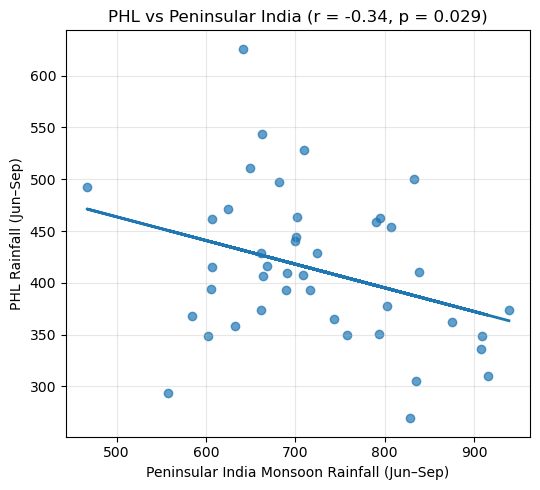

In [14]:
import numpy as np

x = df["Monsoon_Season"]
y = df["annual"]

# Linear fit
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Peninsular India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Peninsular India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Alternative**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, t

ALPHA = 0.05  # 95% confidence level

correlation_targets = {
    "Whole_IND": "PHL vs Whole India",
    "Central_IND": "PHL vs Central India",
    "NE_IND": "PHL vs NE India",
    "NW_IND": "PHL vs NW India",
    "Peninsula_IND": "PHL vs Peninsular India",
}

In [16]:
results = {}

for key, label in correlation_targets.items():

    df_corr = pd.merge(
        phl[["Year", "annual"]],
        ind[key][["Year", "Monsoon_Season"]],
        on="Year",
        how="inner"
    ).dropna()

    x = df_corr["Monsoon_Season"]
    y = df_corr["annual"]

    # Pearson correlation
    r, p = pearsonr(x, y)

    # Student's t-test
    n = len(df_corr)
    dfree = n - 2
    t_stat = r * np.sqrt(dfree / (1 - r**2))
    p_t = 2 * (1 - t.cdf(abs(t_stat), df=dfree))
    t_crit = t.ppf(1 - ALPHA/2, df=dfree)

    results[key] = {
        "label": label,
        "n": n,
        "r": r,
        "p": p,
        "t_stat": t_stat,
        "t_crit": t_crit,
        "significant_95": abs(t_stat) > t_crit,
        "df": df_corr
    }

In [17]:
for key, res in results.items():
    print(f"\n{res['label']}")
    print("-" * len(res["label"]))
    print(f"Sample size (n): {res['n']}")
    print(f"Pearson r: {res['r']:.3f}")
    print(f"t-statistic: {res['t_stat']:.3f}")
    print(f"Critical t (95% CL): ±{res['t_crit']:.3f}")
    print(f"p-value: {res['p']:.4f}")

    if res["significant_95"]:
        print("Result: Significant at the 95% confidence level")
    else:
        print("Result: Not significant at the 95% confidence level")


PHL vs Whole India
------------------
Sample size (n): 42
Pearson r: -0.193
t-statistic: -1.245
Critical t (95% CL): ±2.021
p-value: 0.2203
Result: Not significant at the 95% confidence level

PHL vs Central India
--------------------
Sample size (n): 42
Pearson r: -0.036
t-statistic: -0.228
Critical t (95% CL): ±2.021
p-value: 0.8206
Result: Not significant at the 95% confidence level

PHL vs NE India
---------------
Sample size (n): 42
Pearson r: -0.291
t-statistic: -1.926
Critical t (95% CL): ±2.021
p-value: 0.0613
Result: Not significant at the 95% confidence level

PHL vs NW India
---------------
Sample size (n): 42
Pearson r: 0.038
t-statistic: 0.243
Critical t (95% CL): ±2.021
p-value: 0.8096
Result: Not significant at the 95% confidence level

PHL vs Peninsular India
-----------------------
Sample size (n): 42
Pearson r: -0.338
t-statistic: -2.269
Critical t (95% CL): ±2.021
p-value: 0.0288
Result: Significant at the 95% confidence level


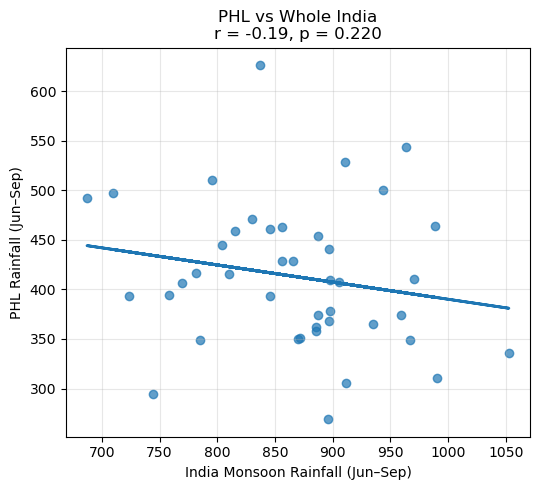

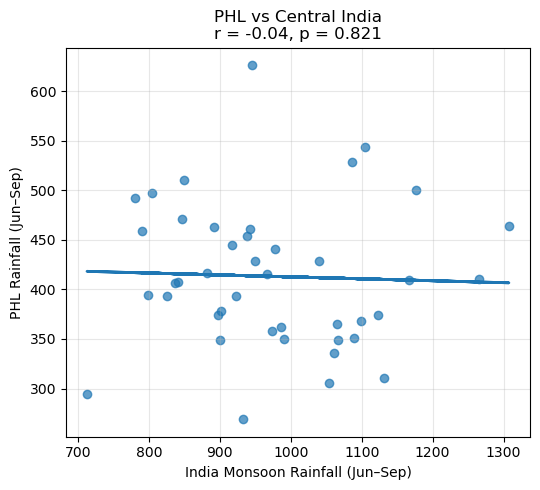

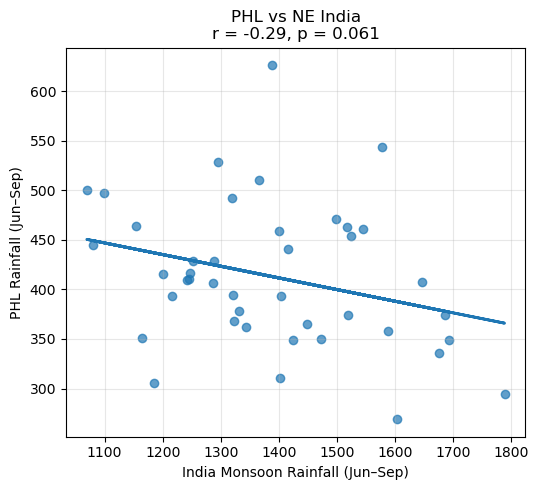

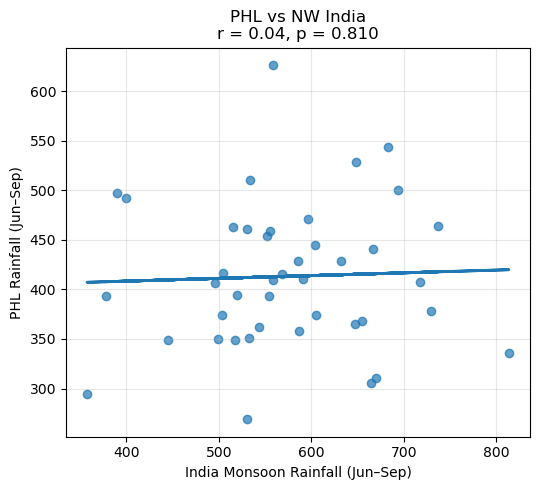

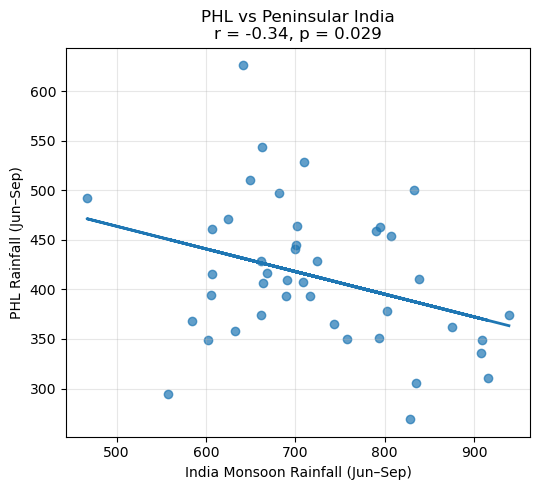

In [18]:
for key, res in results.items():

    dfp = res["df"]
    x = dfp["Monsoon_Season"]
    y = dfp["annual"]

    m, b = np.polyfit(x, y, 1)

    plt.figure(figsize=(5.5, 5))
    plt.scatter(x, y, alpha=0.7)
    plt.plot(x, m*x + b, linewidth=2)

    plt.xlabel("India Monsoon Rainfall (Jun–Sep)")
    plt.ylabel("PHL Rainfall (Jun–Sep)")
    plt.title(
        f"{res['label']}\n"
        f"r = {res['r']:.2f}, p = {res['p']:.3f}"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()